## Info about parakeet

In [ ]:
from pathlib import Path
import nemo.collections.asr as nemo_asr

model_path = Path(".cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v3/snapshots/7c35754d166cca382ad1e53e68b01e7c575f3a1d/parakeet-tdt-0.6b-v3.nemo")
model = nemo_asr.models.ASRModel.restore_from(str(model_path))

/home/mpasqual/miniconda3/envs/simsamu_asr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[NeMo W 2026-07-17 21:36:13 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


[NeMo I 2026-07-17 21:36:23 mixins:184] Tokenizer SentencePieceTokenizer initialized with 8192 tokens


[NeMo W 2026-07-17 21:36:26 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 10.0
    min_duration: 1.0
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-07-17 21:36:26 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation 

[NeMo I 2026-07-17 21:36:32 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-07-17 21:36:32 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}


[NeMo W 2026-07-17 21:36:32 label_looping_base:125] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: CUDA is not available


[NeMo I 2026-07-17 21:36:32 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}


[NeMo W 2026-07-17 21:36:32 label_looping_base:125] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: CUDA is not available


[NeMo I 2026-07-17 21:36:35 save_restore_connector:285] Model EncDecRNNTBPEModel was successfully restored from /home/mpasqual/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v3/snapshots/7c35754d166cca382ad1e53e68b01e7c575f3a1d/parakeet-tdt-0.6b-v3.nemo.


In [6]:
# Print all internal functions and properties
print(dir(model)) 

['AGGREGATE_TOKENIZERS_DICT_PREFIX', 'CHECKPOINT_HYPER_PARAMS_KEY', 'CHECKPOINT_HYPER_PARAMS_NAME', 'CHECKPOINT_HYPER_PARAMS_TYPE', 'T_destination', '_LightningModule__check_allowed', '_LightningModule__check_not_nested', '_LightningModule__to_tensor', '_Typing__attach_neural_type', '_Typing__check_neural_type', '__abstractmethods__', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__jit_unused_properties__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_apply', '_apply_batch_transfer_handler', '_attach_and_validate_output_types', '_automatic_optimization', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_batch_hook', '_cal

In [7]:
# Look at the underlying neural network architecture layout
print(model.summarize())

  | Name              | Type                              | Params | Mode 
--------------------------------------------------------------------------------
0 | preprocessor      | AudioToMelSpectrogramPreprocessor | 0      | train
1 | encoder           | ConformerEncoder                  | 608 M  | train
2 | decoder           | RNNTDecoder                       | 11.8 M | train
3 | joint             | RNNTJoint                         | 6.3 M  | train
4 | loss              | RNNTLoss                          | 0      | train
5 | spec_augmentation | SpectrogramAugmentation           | 0      | train
6 | wer               | WER                               | 0      | train
--------------------------------------------------------------------------------
627 M     Trainable params
0         Non-trainable params
627 M     Total params
2,508.033 Total estimated model params size (MB)
706       Modules in train mode
0         Modules in eval mode


In [8]:
if hasattr(model, "tokenizer"):
    # Prints the actual character/byte-pair tokens the model outputs
    print(model.tokenizer.vocab)

['<unk>', '<|nospeech|>', '<pad>', '<|endoftext|>', '<|startoftranscript|>', '<|pnc|>', '<|nopnc|>', '<|startofcontext|>', '<|itn|>', '<|noitn|>', '<|timestamp|>', '<|notimestamp|>', '<|diarize|>', '<|nodiarize|>', '<|spkchange|>', '<|audioseparator|>', '<|emo:undefined|>', '<|emo:neutral|>', '<|emo:happy|>', '<|emo:sad|>', '<|emo:angry|>', '<|unklang|>', '<|predict_lang|>', '<|nopredict_lang|>', '<|aa|>', '<|ab|>', '<|af|>', '<|ak|>', '<|sq|>', '<|am|>', '<|ar|>', '<|an|>', '<|hy|>', '<|as|>', '<|av|>', '<|ae|>', '<|ay|>', '<|az|>', '<|bm|>', '<|ba|>', '<|eu|>', '<|be|>', '<|bn|>', '<|bi|>', '<|bs|>', '<|br|>', '<|bg|>', '<|my|>', '<|ca|>', '<|ch|>', '<|ce|>', '<|ny|>', '<|zh|>', '<|cu|>', '<|cv|>', '<|kw|>', '<|co|>', '<|cr|>', '<|hr|>', '<|cs|>', '<|da|>', '<|dv|>', '<|nl|>', '<|dz|>', '<|en|>', '<|eo|>', '<|et|>', '<|ee|>', '<|fo|>', '<|fj|>', '<|fi|>', '<|fr|>', '<|fy|>', '<|ff|>', '<|gd|>', '<|gl|>', '<|lg|>', '<|ka|>', '<|de|>', '<|el|>', '<|kl|>', '<|gn|>', '<|gu|>', '<|ht|>', 

In [9]:
help(model.transcribe)

Help on method transcribe in module nemo.collections.asr.models.rnnt_models:

transcribe(audio: Union[str, List[str], numpy.ndarray, torch.utils.data.dataloader.DataLoader], use_lhotse: bool = True, batch_size: int = 4, return_hypotheses: bool = False, partial_hypothesis: Optional[List[ForwardRef('Hypothesis')]] = None, num_workers: int = 0, channel_selector: Union[int, Iterable[int], str, NoneType] = None, augmentor: omegaconf.dictconfig.DictConfig = None, verbose: bool = True, timestamps: Optional[bool] = None, override_config: Optional[nemo.collections.asr.parts.mixins.transcription.TranscribeConfig] = None) -> Union[List[str], List[nemo.collections.asr.parts.utils.rnnt_utils.Hypothesis], Tuple[List[str]], Tuple[List[nemo.collections.asr.parts.utils.rnnt_utils.Hypothesis]]] method of nemo.collections.asr.models.rnnt_bpe_models.EncDecRNNTBPEModel instance
    Uses greedy decoding to transcribe audio files. Use this method for debugging and prototyping.

    Args:
        audio: (a si

In [10]:
audios_path = Path("/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios")
audios = [f for f in audios_path.iterdir() if f.is_file()]

audios

[PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_2022_douleur_abdo_dj_2022_douleur_abdo.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_mai_feu_grand_pere_dj_mai_feu_grand_pere.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_2022_douleur_thorax_dj_2022_douleur_thorax.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_mai_malaise_dt_dj_mai_malaise_dt.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/reu_ncb_reu_ncb.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_mai_sdf_coma_dj_mai_sdf_coma.m4a'),
 PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_2022

In [ ]:
audios[0]

PosixPath('/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/simsamu_asr/simsamu/audios/dj_2022_douleur_abdo_dj_2022_douleur_abdo.m4a')

: 

In [ ]:
transcription_test = model.transcribe([str(audios[0])])[0]
transcription_test

[NeMo W 2026-07-17 21:36:35 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-07-17 21:36:35 dataloader:523] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
Transcribing: 0it [00:00, ?it/s]

In [ ]:
def load_resample_audio(audio_path: str, target_sr: int = 16000):
    """Load audio and, when needed, write a temporary 16kHz wav file for NeMo."""

    audio_path = Path(audio_path)
    temp_dir = None
    
    # Try to fetch the original sample rate safely
    try:
        orig_sr = librosa.get_samplerate(str(audio_path))
    except Exception:
        orig_sr = None  # Fallback if the format doesn't support direct metadata reading

    # Resample only if it's an .m4a file OR if the sample rate isn't 16000 Hz
    if audio_path.suffix.lower() == ".m4a" or (orig_sr and orig_sr != target_sr):
        # Load at native rate (sr=None prevents automatic resampling on load)
        y, sr = librosa.load(str(audio_path), sr=None)
        
        # Resample explicitly using kaiser_best
        audio_resampled = librosa.resample(
            y, 
            orig_sr=sr, 
            target_sr=target_sr, 
            res_type="kaiser_best"
        )
        temp_dir = tempfile.TemporaryDirectory()
        wav_path = Path(temp_dir.name) / f"{audio_path.stem}.wav"
        sf.write(str(wav_path), audio_resampled, target_sr)
        return str(wav_path), temp_dir
        
    else:
        # For .wav files already at 16k, load directly with zero extra processing
        return str(audio_path), temp_dir

# Normalization attempts

`jiwer` classes

In [26]:
import jiwer
import re
from unidecode import unidecode
from number2text.number2text import NumberToText
from text_to_num import text2num

In [ ]:
class TransformHours(jiwer.transforms.AbstractTransform):
    def process_string(self, txt: str):
        new_txt = re.sub(r"(\d+)\s*(h)eures", r"\1\2", txt)
        pattern = re.compile(r"(\d{1,2}h)\s(\d{2}[^h])", flags=re.MULTILINE)
        return pattern.sub(r"\1\2", new_txt)

class TransformNum2Text(jiwer.transforms.AbstractTransform):
    def process_string(self, txt: str):
        converter = NumberToText(language="fr")
        new_txt = []
        for w in txt.split():
            try:
                int_nb = int(w)
                new_txt.append(converter.convert(int_nb))
            except:
                new_txt.append(w)
        return " ".join(new_txt)
    
class TransformText2Num(jiwer.transforms.AbstractTransform):
    def process_string(self, txt: str):
        try:
            # text2num converts whole sentences containing spelled-out numbers natively
            return text2num(txt, "fr")
        except Exception:
            return txt
        
class TransformText2Num(jiwer.transforms.AbstractTransform):
    def process_string(self, txt: str):
        def convert_token(token: str) -> str:
            try:
                return str(text2num(token, "fr"))
            except ValueError:
                return token 
            
        tokens = txt.split()
        return " ".join(convert_token(token) for token in tokens) 

# Compose pipeline
NORMALIZATION_PIPELINE = jiwer.Compose([
    jiwer.RemoveEmptyStrings(),
    jiwer.ToLowerCase(),
    # jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.SubstituteRegexes({r"oe": r"œ"}),
    TransformHours(),
    TransformNum2Text(),
    TransformText2Num(),
    jiwer.RemovePunctuation(),
])

# Create a clean wrapper function to normalize strings on-the-fly
def normalize_text(text: str) -> str:
    # Run the pipeline
    word_list = NORMALIZATION_PIPELINE(text)
    # Reconstruct back into a clean string sentence
    # return " ".join(word_list)
    return word_list

# --- Example Usage ---
if __name__ == "__main__":
    raw_sample = "Bonjour je suis au dix et au dix-huit"
    
    cleaned_sample = normalize_text(raw_sample)
    print("Before:", raw_sample)
    print("After :", cleaned_sample)

Before: Bonjour je suis au dix et au dix-huit
After : bonjour je suis au 10 et au 18


# Experimenting with evaluation metrics

## Text-to-text alignment algorithm

Considerations: meh, doesn't add much to my purpose.

In [1]:
from error_align import error_align

In [ ]:
from pathlib import Path

test_h = Path("/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/benchmarking_asr_medical/simsamu/texts_preprocessed/dj_2022_3_mois_paracetamol/dj_2022_3_mois_paracetamol.txt")
test_gt = Path("/srv/storage/semagramme@storage1.nancy.grid5000.fr/users/mpasqual/benchmarking_asr_medical/simsamu/output_parakeet/dj_2022_3_mois_paracetamol_dj_2022_3_mois_paracetamol.txt")

with open(test_h, "r", encoding="utf-8") as f:
    text_test_h = f.read()

with open(test_gt, "r", encoding="utf-8") as f:
    text_test_gt = f.read()

In [4]:
# Compute alignment
alignments = error_align(text_test_gt, text_test_h)

# Print individual word-level mappings
for align in alignments:
    print(align)

Alignment(MATCH: "allo" == "Allo")
Alignment(INSERT: "allo")
Alignment(INSERT: "madame")
Alignment(MATCH: "oui" == "Oui")
Alignment(MATCH: "allo" == "allo")
Alignment(MATCH: "allo" == "allo")
Alignment(MATCH: "oui" == "Oui")
Alignment(MATCH: "bonjour" == "bonjour")
Alignment(MATCH: "je" == "je")
Alignment(MATCH: "suis" == "suis")
Alignment(MATCH: "le" == "le")
Alignment(MATCH: "docteur" == "docteur")
Alignment(SUBSTITUTE: "LAKHLIFI" -> "Laxifi")
Alignment(MATCH: "vous" == "Vous")
Alignment(MATCH: "m'appelez" == "m'appelez")
Alignment(MATCH: "pour" == "pour")
Alignment(DELETE: "voir")
Alignment(MATCH: "votre" == "votre")
Alignment(MATCH: "enfant" == "enfant")
Alignment(MATCH: "qui" == "qui")
Alignment(MATCH: "a" == "a")
Alignment(MATCH: "bien" == "bien")
Alignment(MATCH: "trois" == "trois")
Alignment(MATCH: "mois" == "mois")
Alignment(MATCH: "c'est" == "c'est")
Alignment(MATCH: "ça" == "ça")
Alignment(MATCH: "oui" == "Oui")
Alignment(MATCH: "c'est" == "c'est")
Alignment(MATCH: "ça" == "

## Exploring `jiwer`'s output

In [ ]:
from pathlib import Path

test_h = Path("simsamu/normalized_texts_RAW/dj_mai_sdf_coma.txt")
test_gt = Path("simsamu/normalized_parakeet/dj_mai_sdf_coma.txt")

with open(test_h, "r", encoding="utf-8") as f:
    text_test_h = f.read()

with open(test_gt, "r", encoding="utf-8") as f:
    text_test_gt = f.read()

In [2]:
text_test_h 

'oui bonjour docteur saeb hum je vous hum vous appelez parce que vous avez trouvé un sdf dans le coma cest bien ça bah je sais pas trop moi il est conscient bah je sais pas est ce quil respire hum jai limpression que que oui il ronfle un peu daccord là vous pouvez le le stimuler un peu pour quil quil ouvre les yeux bah heu jai pas très envie de mapprocher il est pas très propre ce monsieur cest un monsieur du quartier madame vous appelez madame vous appelez il il faut que vous vous rapprochiez de lui et que vous le stimuliez un peu approchez vous de lui bon daccord hum heu là je lui ai secoué un peu lépaule il il grogne il me repousse daccord donc il parle cest ça bah il grogne je comprends pas ce quil dit daccord hum vous vous allez rester près de lui hum on va envoyer les pompiers vous restez près de lui jusquà larrivée des pompiers et on envoie les pompiers ok bah merci pardon de vous avoir dérangé hein docteur non non pas de soucis'

In [3]:
text_test_gt

'oui bonjour docteur saeb je vous vous vous appelez parce que vous avez trouvé un sdf dans le coma cest bien ça bah je sais pas trop moi il est conscient ben je sais pas estce quil respire jai limpression que oui il ronfle un peu daccord là vous pouvez le le stimuler un peu pour quil ouvre les yeux bah jai pas très envie de mapprocher il nest pas très propre ce monsieur cest un monsieur du quartier madame vous appelez mais madame vous appelez il faut que vous rapprochez de lui et que vous le simulez un peu approchezvous de lui bon daccord là je lui ai secoué un peu lépaule il grogne il me repousse daccord donc il parle cest ça bah il grogne je comprends pas ce quil dit daccord vous vous allez rester près de lui on va envoyer les pompiers vous restez près de lui jusquà larrivée des pompiers et on envoie les pompiers ok bah merci pardon de vous avoir dérangé hein docteur non non pas de soucis'

In [4]:
import jiwer
from jiwer import wer

wer = jiwer.wer(text_test_gt, text_test_h)
print(f"Word Error Rate (WER): {wer:.2%}")

Word Error Rate (WER): 12.57%


In [5]:
measures = jiwer.compute_measures(text_test_gt, text_test_h)
measures

{'wer': 0.12571428571428572,
 'mer': 0.1164021164021164,
 'wil': 0.1523100303951367,
 'wip': 0.8476899696048633,
 'hits': 167,
 'substitutions': 7,
 'deletions': 1,
 'insertions': 14,
 'ops': [[AlignmentChunk(type='equal', ref_start_idx=0, ref_end_idx=4, hyp_start_idx=0, hyp_end_idx=4),
   AlignmentChunk(type='insert', ref_start_idx=4, ref_end_idx=4, hyp_start_idx=4, hyp_end_idx=5),
   AlignmentChunk(type='equal', ref_start_idx=4, ref_end_idx=6, hyp_start_idx=5, hyp_end_idx=7),
   AlignmentChunk(type='substitute', ref_start_idx=6, ref_end_idx=7, hyp_start_idx=7, hyp_end_idx=8),
   AlignmentChunk(type='equal', ref_start_idx=7, ref_end_idx=31, hyp_start_idx=8, hyp_end_idx=32),
   AlignmentChunk(type='substitute', ref_start_idx=31, ref_end_idx=32, hyp_start_idx=32, hyp_end_idx=33),
   AlignmentChunk(type='equal', ref_start_idx=32, ref_end_idx=35, hyp_start_idx=33, hyp_end_idx=36),
   AlignmentChunk(type='insert', ref_start_idx=35, ref_end_idx=35, hyp_start_idx=36, hyp_end_idx=37),
   Alig

In [6]:
schema = jiwer.process_words(text_test_gt, text_test_h)
print(jiwer.visualize_alignment(schema))

sentence 1
REF: oui bonjour docteur saeb *** je vous vous vous appelez parce que vous avez trouvé un sdf dans le coma cest bien ça bah je sais pas trop moi il est conscient ben je sais pas *** estce quil respire *** jai limpression que *** oui il ronfle un peu daccord là vous pouvez le le stimuler un peu pour quil **** ouvre les yeux bah *** jai pas très envie de mapprocher il nest pas très propre ce monsieur cest un monsieur du quartier madame vous appelez mais madame vous appelez il ** faut que vous ****  rapprochez de lui et que vous le   simulez un peu ********* approchezvous de lui bon daccord *** *** là je lui ai secoué un peu lépaule il ** grogne il me repousse daccord donc il parle cest ça bah il grogne je comprends pas ce quil dit daccord *** vous vous allez rester près de lui *** on va envoyer les pompiers vous restez près de lui jusquà larrivée des pompiers et on envoie les pompiers ok bah merci pardon de vous avoir dérangé hein docteur non non pas de soucis
HYP: oui bonjour

In [7]:
schema_chars = jiwer.process_characters(text_test_gt, text_test_h)
print(jiwer.visualize_alignment(schema_chars))

sentence 1
REF: oui bonjour docteur saeb ****je vous vous vous appelez parce que vous avez trouvé un sdf dans le coma cest bien ça bah je sais pas trop moi il est conscient ben je sais pas est*ce quil respire ****jai limpression que ****oui il ronfle un peu daccord là vous pouvez le le stimuler un peu pour quil *****ouvre les yeux bah ****jai pas très envie de mapprocher il nest pas très propre ce monsieur cest un monsieur du quartier madame vous appelez mais madame vous appelez il ***faut que vous *****rapproch*ez de lui et que vous le s*imul*ez un peu approchez*vous de lui bon daccord ********là je lui ai secoué un peu lépaule il ***grogne il me repousse daccord donc il parle cest ça bah il grogne je comprends pas ce quil dit daccord ****vous vous allez rester près de lui**** on va envoyer les pompiers vous restez près de lui jusquà larrivée des pompiers et on envoie les pompiers ok bah merci pardon de vous avoir dérangé hein docteur non non pas de soucis
HYP: oui bonjour docteur sae

In [ ]:
# How long are the files

transcriptions = Path("simsamu/normalized_texts_RAW")
print(f"Number of transcription files: {len(list(transcriptions.rglob('*.txt')))}")

Number of transcription files: 61


In [13]:
for transcription_file in transcriptions.rglob("*.txt"):
    with open(transcription_file, "r", encoding="utf-8") as f:
        text = f.read()
    print(f"{transcription_file.name}, {len(text.split())} tokens")

dj_2022_va_accoucher.txt, 307 tokens
dj_mai_brulures_ms.txt, 642 tokens
dj_2022_arme_2.txt, 557 tokens
dj_2022_msn.txt, 293 tokens
dj_2022_douleur_thorax.txt, 556 tokens
dj_mai_asthme_vento.txt, 481 tokens
dj_2022_grand_mere_repond_plus.txt, 437 tokens
dj_2023_hematemese.txt, 683 tokens
dj_mai_vomi_tc.txt, 368 tokens
dj_2022_coup_enfant.txt, 388 tokens
dj_mai_privileges_malaise.txt, 649 tokens
reu_constipe.txt, 823 tokens
dj_2022_tetanie.txt, 544 tokens
dj_2022_intox_med.txt, 851 tokens
dj_2022_ne_reagit_pas.txt, 710 tokens
dj_mai_enfant_pendu.txt, 288 tokens
dj_2022_mere_fievre.txt, 565 tokens
dj_mai_moto_landy.txt, 758 tokens
dj_mai_malaise_stef.txt, 714 tokens
dj_2023_coups.txt, 819 tokens
dj_mai_ivresse_14_ans.txt, 536 tokens
reu_feu.txt, 752 tokens
dj_2022_grand_mere_battue.txt, 1132 tokens
dj_2023_psy.txt, 605 tokens
dj_mai_intox_bzd.txt, 391 tokens
dj_2022_3_mois_paracetamol.txt, 463 tokens
dj_2023_da.txt, 430 tokens
dj_mai_malaise_joyeux.txt, 580 tokens
dj_2022_voisine_frappee.

In [2]:
from pathlib import Path

hs = Path("simsamu/normalized_parakeet")
gts = Path("simsamu/normalized_texts_RAW")

In [5]:
import jiwer

In [10]:
for h in hs.rglob("*.txt"):
    gt = gts / h.name

    with open(h, "r", encoding="utf-8") as f:
        text_h = f.read()

    with open(gt, "r", encoding="utf-8") as f:
        text_gt = f.read()

    out_complete = jiwer.process_words(text_gt, text_h)

    # Print the top 10 most frequent substitutions, insertions, and deletions
    print(jiwer.visualize_alignment(out_complete))

sentence 1
REF: bonjour madame oui oui docteur  shitz  hum celle du  samu alors votre sœur est en train daccoucher cest ça bah ouais ouais ouais ouais là elle est en train je pense hein parce    que y a tout le bordel partout là hum ok faut faut venir la chercher cest plus possible hein madame elle est a combien de  semaine là votre sœur mais jen sais rien elle devait pas * accoucher avant un mois et là cest le bordel partout heu moi cest bon là faut venir la récupérer ** y a   de ok madame   ce quon va faire on va vous envoyer les pompiers allo les pompiers mais pourquoi les pompiers mais attendez elle je sais pas là elle a mal elle est je sais pas la perte des eaux là là tout ça là bah justement juste y en a partout dans mon salon là moi mon   salon il est mort là quoi heu le salon oui heu madame madame on vous envoie les pompiers restez avec elle préparez du linge propre   mettez là à laise attendez oui madame é écoutez moi mettez là au assise vous     me vous préparez du linge prop

In [12]:
import jiwer

all_gt = []
all_h = []

# 1. Collect all texts across files
for h in hs.rglob("*.txt"):
    gt = gts / h.name

    with open(h, "r", encoding="utf-8") as f:
        all_h.append(f.read())

    with open(gt, "r", encoding="utf-8") as f:
        all_gt.append(f.read())

# 2. Process ALL files together
out_complete = jiwer.process_words(all_gt, all_h)

# 3. Print complete dataset totals
print("Insertions:   ", out_complete.insertions)
print("Deletions:    ", out_complete.deletions)
print("Substitutions:", out_complete.substitutions)
print("Hits:         ", out_complete.hits)
print("Dataset WER:  ", out_complete.wer)

Insertions:    526
Deletions:     5148
Substitutions: 3083
Hits:          27126
Dataset WER:   0.24767372797465848


In [ ]:
import json

# Load file
with open("simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche.json", "r", encoding="utf-8") as f:
    data = json.load(f)
# Quick interactive tagger
for turn in data["monologues"]:
    for term in turn["terms"]:
        if term.get("type") == "WORD":
            word = term["text"]
            # Skip short common words automatically if desired
            ans = input(f"Is '{word}' medical? (y/N): ").strip().lower()
            if ans == "y":
                term["is_medical"] = True

# Save updated JSON automatically without syntax/comma errors!
with open("simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

In [1]:
import json
import streamlit as st

st.set_page_config(page_title="Medical Term Tagger", layout="centered")

# Initialize session state for file data & current index
if "data" not in st.session_state:
    with open("simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche.json", "r", encoding="utf-8") as f:
        st.session_state.data = json.load(f)

    # Flatten all words into a simple list for easy index navigation
    st.session_state.words = []
    for turn in st.session_state.data["monologues"]:
        speaker = turn.get("speaker", {}).get("id", "Unknown")
        for term in turn.get("terms", []):
            if term.get("type") == "WORD":
                st.session_state.words.append((speaker, term))

if "index" not in st.session_state:
    st.session_state.index = 0

words = st.session_state.words
idx = st.session_state.index

st.title("🏥 Medical Entity Tagger")
st.progress(idx / len(words) if words else 1.0)

if idx < len(words):
    speaker, term = words[idx]

    st.subheader(f"Word {idx + 1} of {len(words)}")
    st.info(f"**Speaker:** {speaker.capitalize()}")
    st.markdown(f"### Current Word: `:red[{term['text']}]`")

    # Toggle checkbox for medical status
    is_med = st.checkbox(
        "Is Medical?",
        value=term.get("is_medical", False),
        key=f"check_{idx}",
    )
    term["is_medical"] = is_med

    # Navigation Buttons
    col1, col2, col3 = st.columns([1, 1, 1])

    with col1:
        if st.button("⬅️ Previous") and idx > 0:
            st.session_state.index -= 1
            st.rerun()

    with col2:
        if st.button("➡️ Next") and idx < len(words) - 1:
            st.session_state.index += 1
            st.rerun()

    with col3:
        if st.button("💾 Save Progress"):
            with open(
                "simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche_annotated.json", "w", encoding="utf-8"
            ) as f:
                json.dump(
                    st.session_state.data, f, indent=2, ensure_ascii=False
                )
            st.success("Saved to simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche_annotated.json!")
else:
    st.success("🎉 All words reviewed!")
    if st.button("💾 Save Final File"):
        with open("simsamu/full_dirs_RAW/dj_2022_arme_blanche/dj_2022_arme_blanche_annotated.json", "w", encoding="utf-8") as f:
            json.dump(st.session_state.data, f, indent=2, ensure_ascii=False)
        st.success("Saved!")

2026-07-23 09:46:34.779 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 09:46:34.780 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 09:46:34.781 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-07-23 09:46:34.783 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 09:46:34.784 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 09:46:34.784 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

# Is WER proportional to the number of characters?

In [2]:
import pandas as pd
df = pd.read_csv("simsamu/WERs_simsamu.csv")
df

,Filename,WER,Number of characters
0,dj_2022_3_mois_paracetamol.txt,0.1901,2132
1,dj_2022_arme_2.txt,0.3627,2088
2,dj_2022_arme_blanche.txt,0.1881,1868
3,dj_2022_avc_16_ans.txt,0.1919,3967
4,dj_2022_avp_scooter.txt,0.2543,1362
...,...,...,...
56,reu_grand_mere.txt,0.2456,3136
57,reu_ncb.txt,0.1921,2006
58,reu_parturiante.txt,0.2168,4092
59,reu_relevage.txt,0.2254,2532


In [5]:
import matplotlib.pyplot as plt

In [6]:
df.describe()

,WER,Number of characters
count,61.000000,61.000000
mean,0.243938,2538.065574
std,0.068098,870.127689
min,0.117000,902.000000
25%,0.196800,1928.000000
50%,0.230600,2540.000000
75%,0.270900,3136.000000
max,0.430000,4834.000000


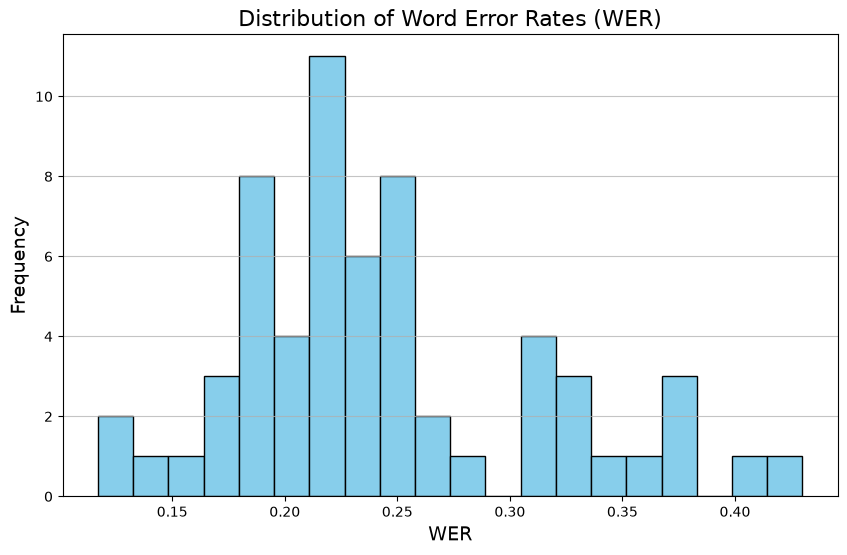

In [9]:
df.columns = df.columns.str.strip()
wers = df['WER']

plt.figure(figsize=(10, 6))
plt.hist(wers, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Word Error Rates (WER)', fontsize=16)
plt.xlabel('WER', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [17]:
import scipy.stats as stats

# Perform Shapiro-Wilk test for normality
shapiro_test_wers = stats.shapiro(wers)
print(f"Shapiro-Wilk Test Statistic for WERs: {shapiro_test_wers.statistic:.4f}, p-value: {shapiro_test_wers.pvalue:.4f}")

Shapiro-Wilk Test Statistic for WERs: 0.9408, p-value: 0.0054


It's not at all normally distributed, both with an $\alpha$ = 0.05 or 0.01. Gotta consider non parametric tests.

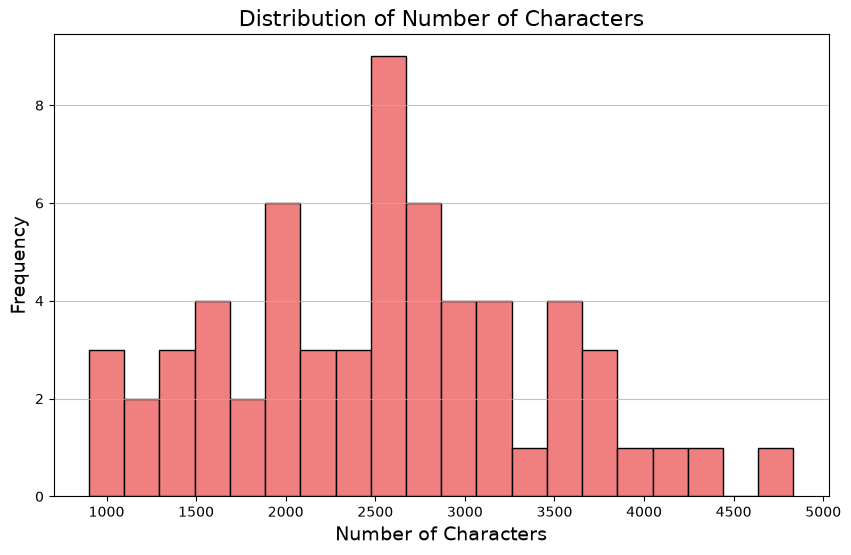

In [12]:
chars = df['Number of characters']

plt.figure(figsize=(10, 6))
plt.hist(chars, bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Number of Characters', fontsize=16)
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [16]:
shapiro_test_chars = stats.shapiro(chars)
print(f"Shapiro-Wilk Test Statistic for Number of Characters: {shapiro_test_chars.statistic:.4f}, p-value: {shapiro_test_chars.pvalue:.4f}")

Shapiro-Wilk Test Statistic for Number of Characters: 0.9880, p-value: 0.8142


The length of the files in number of characters is normally distributed.

### Computing Spearman's Correlation

In [ ]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(chars, wers)  

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p_value:.4e}")

Spearman correlation: 0.098
p-value: 4.5222e-01


Result is very weakly (insignificantly) positive - WER higher for shorter transcripts, towards _negative monotonic relationship, i.e. one variable increases when the other decreases_

Therefore WER and length of the transcripts have no meaningful relationship. There's no monotonic association.

In [20]:
import seaborn as sns

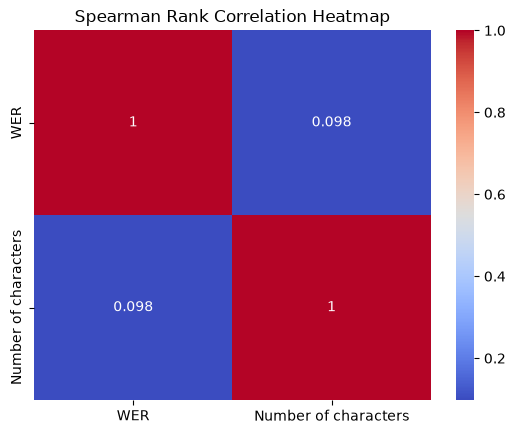

In [22]:
corr_data = df[['WER', 'Number of characters']].corr(method='spearman')

sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Spearman Rank Correlation Heatmap")
plt.show()

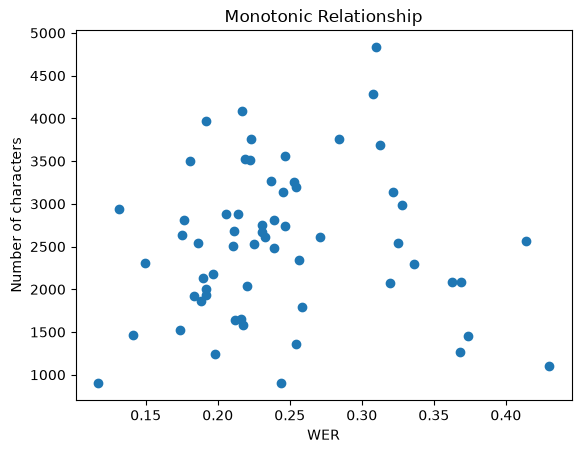

In [23]:
plt.scatter(df['WER'], df['Number of characters'])
plt.xlabel("WER")
plt.ylabel("Number of characters")
plt.title("Monotonic Relationship")
plt.show()

# Figuring out "interactive" annotation

In [2]:
import json
from pathlib import Path
import jiwer
import pandas as pd

# --- 1. Define Paths to a Single File Pair ---
hyp_path = Path("simsamu/normalized_parakeet/dj_2022_3_mois_paracetamol.txt")
gt_path = Path("simsamu/normalized_annotated/dj_2022_3_mois_paracetamol_annotated.json")


# --- 2. Helper to Extract Words & Medical Flags from JSON ---
def extract_gt_from_json(json_path: Path):
    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    ref_words = []
    is_medical_flags = []

    for turn in data.get("monologues", []):
        for term in turn.get("terms", []):
            if term.get("type") == "WORD" and "text" in term:
                word = term["text"].strip()
                if word:
                    ref_words.append(word)
                    is_medical_flags.append(term.get("is_medical", False))

    return ref_words, is_medical_flags


# --- 3. Read Data & Process Alignment ---
ref_words, is_med_flags = extract_gt_from_json(gt_path)
ground_truth_text = " ".join(ref_words)

with hyp_path.open("r", encoding="utf-8") as f:
    hypothesis_text = f.read().strip()

out = jiwer.process_words(ground_truth_text, hypothesis_text)
hyp_words = hypothesis_text.split()

# --- 4. Visual Alignment Overview ---
print("================ JiWER Standard Alignment ================")
print(jiwer.visualize_alignment(out))
print("==========================================================")

# --- 5. Granular Token-by-Token Inspection ---
alignment_details = []

for chunk in out.alignments[0]:
    op_type = chunk.type

    if op_type == "equal":
        for r_idx, h_idx in zip(
            range(chunk.ref_start_idx, chunk.ref_end_idx),
            range(chunk.hyp_start_idx, chunk.hyp_end_idx),
        ):
            alignment_details.append({
                "Operation": "MATCH",
                "Reference": ref_words[r_idx],
                "Hypothesis": hyp_words[h_idx],
                "Is_Medical": is_med_flags[r_idx],
                "Medical_Error": False,
            })

    elif op_type == "substitute":
        for r_idx, h_idx in zip(
            range(chunk.ref_start_idx, chunk.ref_end_idx),
            range(chunk.hyp_start_idx, chunk.hyp_end_idx),
        ):
            is_med = is_med_flags[r_idx]
            alignment_details.append({
                "Operation": "SUBSTITUTION",
                "Reference": ref_words[r_idx],
                "Hypothesis": hyp_words[h_idx],
                "Is_Medical": is_med,
                "Medical_Error": is_med,
            })

    elif op_type == "delete":
        for r_idx in range(chunk.ref_start_idx, chunk.ref_end_idx):
            is_med = is_med_flags[r_idx]
            alignment_details.append({
                "Operation": "DELETION",
                "Reference": ref_words[r_idx],
                "Hypothesis": "<DELETED>",
                "Is_Medical": is_med,
                "Medical_Error": is_med,
            })

    elif op_type == "insert":
        for h_idx in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
            alignment_details.append({
                "Operation": "INSERTION",
                "Reference": "<INSERTED>",
                "Hypothesis": hyp_words[h_idx],
                "Is_Medical": is_med,
                "Medical_Error": is_med,
            })

# Convert to Pandas DataFrame for clean viewing in Jupyter
df_align = pd.DataFrame(alignment_details)

# --- 6. Display Filtered Views ---
print("\n--- Summary Statistics ---")
print(f"Total Words: {len(ref_words)}")
print(f"Medical Words: {sum(is_med_flags)}")
print(f"Medical Errors: {df_align['Medical_Error'].sum()}")

print("\n--- Medical Terms Only Breakdown ---")
# Filter dataframe to show only rows where the reference word was tagged as medical
display(df_align[df_align["Is_Medical"] == True])

================ JiWER Standard Alignment ================
sentence 1
REF: allo allo madame oui allo allo oui bonjour je suis le docteur lakhlifi vous mappelez pour **** votre enfant qui a bien trois mois cest ça oui cest ça cest ça exactement ça fait heu jattends depuis **** longtemps là hum daccord il a pris des médicaments quil aurait pas dû prendre oui cest ça cest ça je pense heu ça fait beaucoup de médicaments là je ** sais pas heu quoi faire jattends depuis très longtemps maintenant je je heu jen suis vraiment désolée on on va essayer dêtre rapides et de trouver la la oui mais moi jattends quoi hein quel médicament atil pris bah cest du            para paracétamol là vous savez oui tout à fait en quelle dose il la il la pris bah je ** sais pas enfin moi euh jai     lhabi enfin jai que   quun  enfant jen donne jai      jai jai je prends pas lhabitude den donner mais là je pense que jai donné un grande dose trois fois la dose quil faut jaurais dû donner et moi on ** me dit pas quo

,Operation,Reference,Hypothesis,Is_Medical,Medical_Error
46,MATCH,médicaments,médicaments,True,False
64,MATCH,médicaments,médicaments,True,False
109,SUBSTITUTION,para,paraparacetamol,True,True
110,DELETION,paracétamol,<DELETED>,True,True
120,MATCH,dose,dose,True,False
160,MATCH,grande,grande,True,False
161,MATCH,dose,dose,True,False
165,MATCH,dose,dose,True,False
218,MATCH,boire,boire,True,False
221,MATCH,manger,manger,True,False
